# Rental Price-Tier Classification & Clustering

**Dataset:** UCI *Apartment for Rent Classified* — real US rental listings.

**Problem.** Each listing's monthly rent is binned into three **price tiers**
(`Budget` / `Mid` / `Premium`) by tertiles. We then:

1. Train, tune and compare **six classifiers** spanning four families
   (distance-based, tree-based, linear, neural network) plus a gradient-boosting
   bridge to the RentWise app and a majority-class baseline.
2. Run a **feature-selection / dimensionality-reduction** study.
3. Experiment with **multiple neural-network architectures**.
4. Train a **regression bridge** (the model RentWise productionises) on raw rent.
5. **Cluster** the listings (labels removed) and compare clusters to the true tiers.

All metrics, tables and figures are written to `../results/`.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Make the portable src/ helpers importable regardless of CWD.
SRC = Path.cwd().parent / "src" if (Path.cwd().name == "notebooks") else Path.cwd() / "src"
sys.path.insert(0, str(SRC.resolve()))

import preprocessing as prep
import evaluation as ev
import clustering as cl

RESULTS = (SRC.parent / "results")
RESULTS.mkdir(exist_ok=True)
print("src:", SRC.resolve())
print("results:", RESULTS.resolve())

src: C:\Users\AralytiKS\Desktop\Lab2\machine_learning\src
results: C:\Users\AralytiKS\Desktop\Lab2\machine_learning\results


## 1. Load & explore the data

In [2]:
# Download on first run (no-op if the CSV already exists).
import download_data
download_data.main()

raw = prep.load_raw()
print("raw shape:", raw.shape)
raw.head()

[skip] C:\Users\AralytiKS\Desktop\Lab2\machine_learning\data\raw\apartments.csv already exists. Delete it to re-download.
raw shape: (10000, 22)


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [3]:
print("Columns:", list(raw.columns))
raw.describe(include="all").T.head(25)

Columns: ['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms', 'currency', 'fee', 'has_photo', 'pets_allowed', 'price', 'price_display', 'price_type', 'square_feet', 'address', 'cityname', 'state', 'latitude', 'longitude', 'source', 'time']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,10000.0,NaN,NaN,NaN,5623395652.8752,70210252.044846,5508654087.0,5509248467.0,5668609592.5,5668626447.25,5668662559.0
category,10000,3,housing/rent/apartment,9996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,10000,9350,Apartment in great location,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
body,10000,9961,"When searching for a pet-friendly One-, Two- a...",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amenities,6451,2254,Parking,229,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bathrooms,9966.0,NaN,NaN,NaN,1.380544,0.61541,1.0,1.0,1.0,2.0,8.5
bedrooms,9993.0,NaN,NaN,NaN,1.744021,0.942354,0.0,1.0,2.0,2.0,9.0
currency,10000,1,USD,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fee,10000,1,No,10000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_photo,10000,3,Thumbnail,8907,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Cleaning, feature engineering & price tiers

In [4]:
df = prep.clean(raw)
print("clean shape:", df.shape)
print("\nFeatures used:")
print("  numeric    :", prep.NUMERIC_FEATURES)
print("  categorical:", prep.CATEGORICAL_FEATURES)
print("\nPrice-tier counts:")
print(df["price_tier"].value_counts())
df.head()

clean shape: (9670, 9)

Features used:
  numeric    : ['square_feet', 'bedrooms', 'bathrooms', 'amenities_count']
  categorical: ['state', 'is_pet_friendly', 'has_photo_flag']

Price-tier counts:
price_tier
Mid        3257
Budget     3235
Premium    3178
Name: count, dtype: int64


,square_feet,bedrooms,bathrooms,amenities_count,state,is_pet_friendly,has_photo_flag,price,price_tier
0,107,0.0,1.0,0,VA,0,1,1390,Mid
1,116,0.0,1.0,0,WA,0,1,925,Budget
2,130,0.0,1.0,5,OTHER,0,1,2475,Premium
3,138,0.0,1.0,1,CA,0,1,1495,Mid
4,190,0.0,1.0,1,CA,0,1,1695,Premium


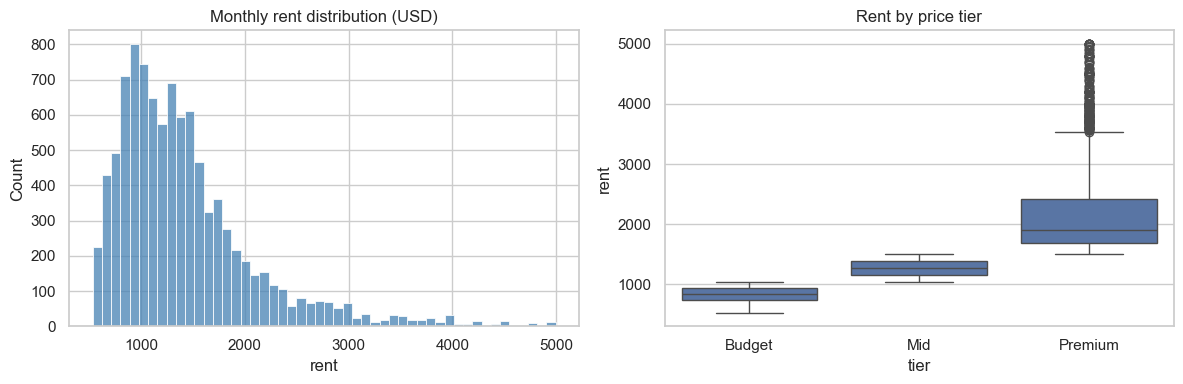

In [5]:
# EDA: rent distribution + tier boundaries
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price"], bins=50, ax=axes[0], color="steelblue")
axes[0].set(title="Monthly rent distribution (USD)", xlabel="rent")
sns.boxplot(data=df, x="price_tier", y="price", order=prep.TIER_LABELS, ax=axes[1])
axes[1].set(title="Rent by price tier", xlabel="tier", ylabel="rent")
fig.tight_layout()
fig.savefig(RESULTS / "eda_price.png", dpi=120, bbox_inches="tight")
plt.show()

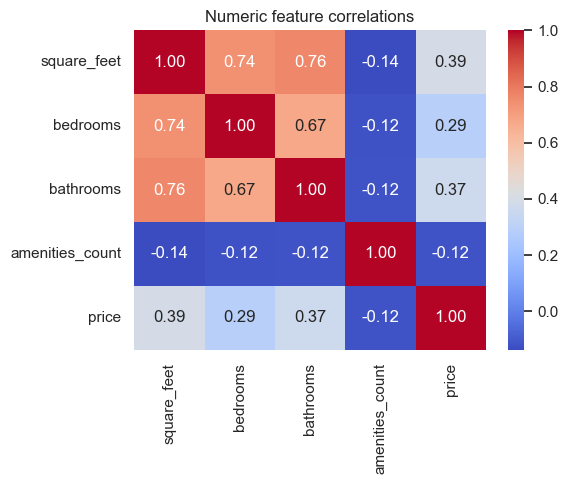

In [6]:
# Feature correlations (numeric)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[prep.NUMERIC_FEATURES + ["price"]].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", ax=ax)
ax.set_title("Numeric feature correlations")
fig.tight_layout()
fig.savefig(RESULTS / "eda_corr.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Train/test split & preprocessing pipeline

In [7]:
X_train, X_test, y_train, y_test = prep.make_splits(df)
labels = prep.TIER_LABELS
print("train:", X_train.shape, " test:", X_test.shape)
print("class balance (train):")
print(y_train.value_counts(normalize=True).round(3))

train: (7736, 7)  test: (1934, 7)
class balance (train):
price_tier
Mid        0.337
Budget     0.335
Premium    0.329
Name: proportion, dtype: float64


## 4. Classifiers — four families + baseline

| Model | Family |
|---|---|
| DummyClassifier | majority-class baseline |
| KNeighborsClassifier | distance-based |
| DecisionTree / RandomForest | tree-based |
| LogisticRegression | linear |
| MLPClassifier | **neural network** |
| GradientBoostingClassifier | boosting (bridge to RentWise) |

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

def make_pipe(estimator):
    return Pipeline([("prep", prep.build_preprocessor()), ("clf", estimator)])

models = {
    "Baseline (majority)":  DummyClassifier(strategy="most_frequent"),
    "KNN":                  KNeighborsClassifier(n_neighbors=15),
    "DecisionTree":         DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "RandomForest":         RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "LogisticRegression":   LogisticRegression(max_iter=1000),
    "MLP (neural net)":     MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=400, random_state=RANDOM_STATE),
    "GradientBoosting":     GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows, fitted = [], {}
for name, est in models.items():
    pipe = make_pipe(est).fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fitted[name] = pipe
    rows.append(ev.score_model(name, y_test, pred))

baseline_table = ev.comparison_table(rows, save=False)
baseline_table.round(4)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,GradientBoosting,0.6370,0.6399,0.6373,0.6349,0.6345
1,KNN,0.6344,0.6366,0.6347,0.6333,0.6328
2,RandomForest,0.6251,0.6268,0.6256,0.6262,0.6256
3,MLP (neural net),0.6220,0.6221,0.6225,0.6223,0.6218
4,LogisticRegression,0.6158,0.6107,0.6165,0.6106,0.6100
5,DecisionTree,0.6086,0.6382,0.6083,0.6082,0.6079
6,Baseline (majority),0.3366,0.1122,0.3333,0.1679,0.1695


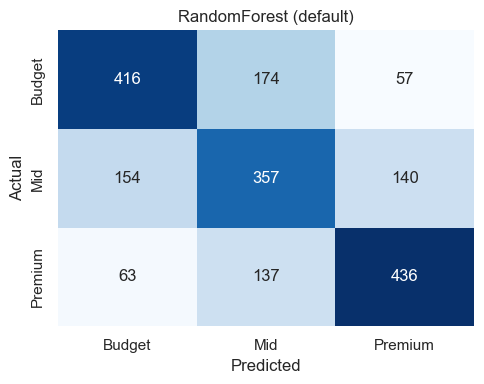

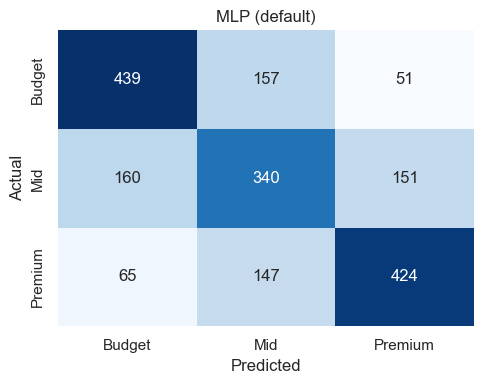

              precision    recall  f1-score   support

      Budget       0.66      0.64      0.65       647
         Mid       0.53      0.55      0.54       651
     Premium       0.69      0.69      0.69       636

    accuracy                           0.63      1934
   macro avg       0.63      0.63      0.63      1934
weighted avg       0.63      0.63      0.63      1934



In [9]:
# Confusion matrices for the baseline and the two strongest default models
ev.plot_confusion(y_test, fitted["RandomForest"].predict(X_test), labels,
                  "RandomForest (default)", "cm_randomforest.png")
ev.plot_confusion(y_test, fitted["MLP (neural net)"].predict(X_test), labels,
                  "MLP (default)", "cm_mlp.png")
print(ev.text_report(y_test, fitted["RandomForest"].predict(X_test)))

## 5. Hyperparameter tuning (GridSearchCV, 5-fold)

For each classifier we search a small, sensible grid and keep the best estimator.
Tested grids and chosen values are printed below and saved to `results/`.

In [10]:
from sklearn.model_selection import GridSearchCV

grids = {
    "KNN": {
        "clf__n_neighbors": [5, 15, 25, 35],
        "clf__weights": ["uniform", "distance"],
    },
    "DecisionTree": {
        "clf__max_depth": [5, 8, 12, None],
        "clf__min_samples_leaf": [1, 5, 20],
    },
    "RandomForest": {
        "clf__n_estimators": [200, 400],
        "clf__max_depth": [None, 12, 20],
    },
    "LogisticRegression": {
        "clf__C": [0.1, 1.0, 10.0],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [2, 3],
        "clf__learning_rate": [0.05, 0.1],
    },
}

tuned_rows, tuned_best = [], {}
tuning_log = []
for name, grid in grids.items():
    gs = GridSearchCV(make_pipe(models[name]), grid, cv=5, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_best[name] = gs.best_estimator_
    pred = gs.best_estimator_.predict(X_test)
    tuned_rows.append(ev.score_model(name + " (tuned)", y_test, pred))
    tuning_log.append({"model": name, "tested": grid, "chosen": gs.best_params_,
                       "cv_f1_macro": round(gs.best_score_, 4)})
    print(f"{name:20s} best={gs.best_params_}  cv_f1={gs.best_score_:.4f}")

pd.DataFrame(tuning_log).to_csv(RESULTS / "hyperparameter_tuning.csv", index=False)

KNN                  best={'clf__n_neighbors': 25, 'clf__weights': 'distance'}  cv_f1=0.6328


DecisionTree         best={'clf__max_depth': None, 'clf__min_samples_leaf': 20}  cv_f1=0.6146


RandomForest         best={'clf__max_depth': 20, 'clf__n_estimators': 200}  cv_f1=0.6500


LogisticRegression   best={'clf__C': 1.0}  cv_f1=0.6186


GradientBoosting     best={'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}  cv_f1=0.6477


## 6. Neural-network architecture experiments

In [11]:
# Vary depth/width and activation; the preprocessing pipeline is shared.
architectures = [
    {"hidden_layer_sizes": (64,),         "activation": "relu"},
    {"hidden_layer_sizes": (128, 64),     "activation": "relu"},
    {"hidden_layer_sizes": (128, 64, 32), "activation": "relu"},
    {"hidden_layer_sizes": (128, 64),     "activation": "tanh"},
]

nn_rows = []
best_mlp, best_f1 = None, -1
for arch in architectures:
    mlp = MLPClassifier(max_iter=500, random_state=RANDOM_STATE, alpha=1e-4, **arch)
    pipe = make_pipe(mlp).fit(X_train, y_train)
    pred = pipe.predict(X_test)
    r = ev.score_model(f"MLP {arch['hidden_layer_sizes']} {arch['activation']}", y_test, pred)
    nn_rows.append(r)
    if r["f1_macro"] > best_f1:
        best_f1, best_mlp = r["f1_macro"], pipe

nn_table = pd.DataFrame(nn_rows)
nn_table.to_csv(RESULTS / "nn_architectures.csv", index=False)
nn_table.round(4)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,"MLP (64,) relu",0.6319,0.6308,0.6323,0.6302,0.6297
1,"MLP (128, 64) relu",0.6220,0.6221,0.6225,0.6223,0.6218
2,"MLP (128, 64, 32) relu",0.6184,0.6152,0.6190,0.6152,0.6146
3,"MLP (128, 64) tanh",0.6091,0.6095,0.6095,0.6074,0.6069


## 7. Feature selection / dimensionality reduction

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

def eval_variant(name, extra_steps):
    pipe = Pipeline([("prep", prep.build_preprocessor()), *extra_steps,
                     ("clf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))])
    pipe.fit(X_train, y_train)
    return ev.score_model(name, y_test, pipe.predict(X_test))

fs_rows = [
    eval_variant("All features", []),
    eval_variant("SelectKBest(k=6)", [("select", SelectKBest(f_classif, k=6))]),
    eval_variant("SelectKBest(k=10)", [("select", SelectKBest(f_classif, k=10))]),
    eval_variant("PCA(5 comps)", [("pca", PCA(n_components=5, random_state=RANDOM_STATE))]),
    eval_variant("PCA(10 comps)", [("pca", PCA(n_components=10, random_state=RANDOM_STATE))]),
]
fs_table = pd.DataFrame(fs_rows)
fs_table.to_csv(RESULTS / "feature_selection.csv", index=False)
fs_table.round(4)

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,All features,0.6241,0.6260,0.6246,0.6252,0.6247
1,SelectKBest(k=6),0.5357,0.5377,0.5362,0.5357,0.5351
2,SelectKBest(k=10),0.5620,0.5612,0.5628,0.5616,0.5609
3,PCA(5 comps),0.5517,0.5512,0.5522,0.5515,0.5511
4,PCA(10 comps),0.5998,0.6005,0.6005,0.6004,0.5998


## 8. Regression bridge to RentWise

In [13]:
# RentWise productionises a GradientBoostingRegressor on raw rent. We train the
# same model here on the real data and report MAE / R^2 as the explicit link.
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

reg_df = df.copy()
Xr = reg_df[prep.NUMERIC_FEATURES + prep.CATEGORICAL_FEATURES]
yr = reg_df["price"]
from sklearn.model_selection import train_test_split
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)

reg = Pipeline([("prep", prep.build_preprocessor()),
                ("gbr", GradientBoostingRegressor(n_estimators=300, max_depth=3, random_state=RANDOM_STATE))])
reg.fit(Xr_tr, yr_tr)
pred = reg.predict(Xr_te)
print(f"MAE: ${mean_absolute_error(yr_te, pred):,.0f}   R^2: {r2_score(yr_te, pred):.3f}")

MAE: $320   R^2: 0.526


## 9. Final classifier comparison

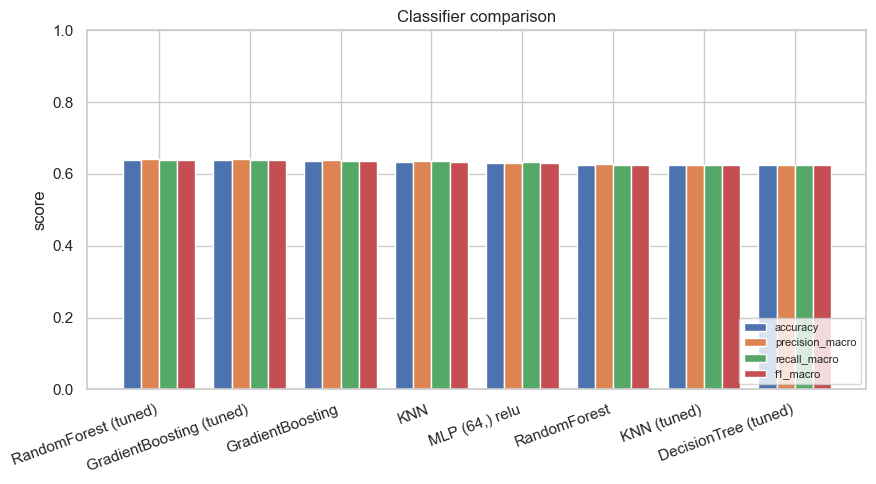

,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,RandomForest (tuned),0.6391,0.6414,0.6394,0.6395,0.6391
1,GradientBoosting (tuned),0.6391,0.6422,0.6393,0.6379,0.6374
2,GradientBoosting,0.6370,0.6399,0.6373,0.6349,0.6345
3,KNN,0.6344,0.6366,0.6347,0.6333,0.6328
4,"MLP (64,) relu",0.6319,0.6308,0.6323,0.6302,0.6297
5,RandomForest,0.6251,0.6268,0.6256,0.6262,0.6256
6,KNN (tuned),0.6241,0.6255,0.6246,0.6248,0.6243
7,DecisionTree (tuned),0.6241,0.6263,0.6244,0.6246,0.6241
8,MLP (neural net),0.6220,0.6221,0.6225,0.6223,0.6218
9,LogisticRegression,0.6158,0.6107,0.6165,0.6106,0.6100


In [14]:
# Combine default + tuned + NN results into one table and plot.
all_rows = rows + tuned_rows + [max(nn_rows, key=lambda r: r['f1_macro'])]
final_table = ev.comparison_table(all_rows, save=True)
ev.plot_comparison_bars(final_table[final_table.model != "Baseline (majority)"].head(8))
final_table.round(4)

## 10. Clustering (labels removed)

We drop the price-tier label, cluster on the preprocessed features, and compare
the discovered clusters to the true tiers with ARI / NMI / homogeneity.

design matrix: (9670, 29)


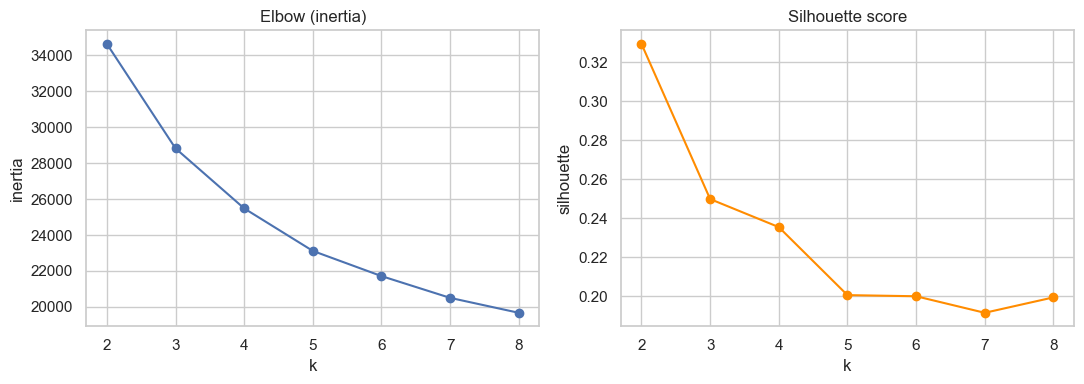

,k,inertia,silhouette
0,2,34632.085,0.329
1,3,28819.085,0.250
2,4,25481.951,0.235
3,5,23116.023,0.201
4,6,21715.716,0.200
5,7,20504.858,0.192
6,8,19673.885,0.199


In [15]:
# Build a numeric design matrix (same preprocessing, no target leakage).
X_all, y_all = prep.feature_matrix(df)
Z = prep.build_preprocessor().fit_transform(X_all)
Z = Z.toarray() if hasattr(Z, "toarray") else np.asarray(Z)
print("design matrix:", Z.shape)

sel = cl.k_selection(Z)
sel.round(3)

init=k-means++  inertia=28,819  ARI=0.058
init=random     inertia=28,819  ARI=0.058


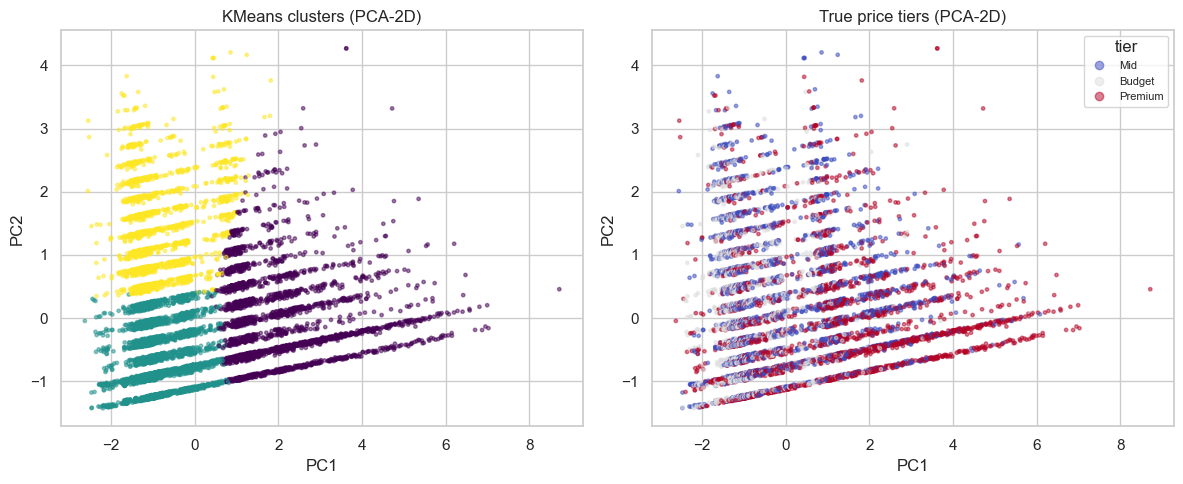

Agreement (KMeans k=3 vs true tiers): {'ARI': 0.058, 'NMI': 0.062, 'homogeneity': 0.061, 'completeness': 0.063}


cluster,0,1,2
true_tier,,,
Budget,320,2007,908
Mid,996,1438,823
Premium,1548,1184,446


In [16]:
from sklearn.cluster import KMeans

# init experiment
for init in ["k-means++", "random"]:
    km = KMeans(n_clusters=3, init=init, n_init=10, random_state=RANDOM_STATE).fit(Z)
    print(f"init={init:10s} inertia={km.inertia_:,.0f}  ARI={cl.agreement(y_all, km.labels_)['ARI']:.3f}")

km = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(Z)
cl.pca_scatter(Z, km.labels_, y_all)
print("Agreement (KMeans k=3 vs true tiers):", {k: round(v, 3) for k, v in cl.agreement(y_all, km.labels_).items()})
cl.contingency(y_all, km.labels_)

In [17]:
# Second algorithm: Agglomerative clustering with different linkages (on a sample for speed).
from sklearn.cluster import AgglomerativeClustering

rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(Z), size=min(4000, len(Z)), replace=False)
Zs, ys = Z[idx], np.asarray(y_all)[idx]

for linkage in ["ward", "average", "complete"]:
    agg = AgglomerativeClustering(n_clusters=3, linkage=linkage).fit(Zs)
    a = cl.agreement(ys, agg.labels_)
    print(f"linkage={linkage:9s} ARI={a['ARI']:.3f}  NMI={a['NMI']:.3f}  homogeneity={a['homogeneity']:.3f}")

linkage=ward      ARI=0.053  NMI=0.057  homogeneity=0.056


linkage=average   ARI=0.002  NMI=0.030  homogeneity=0.017


linkage=complete  ARI=0.008  NMI=0.052  homogeneity=0.035


## 11. Summary

- The comparison table (`results/model_comparison.csv`) ranks all classifiers by macro-F1.
- Tuning grids and chosen values are in `results/hyperparameter_tuning.csv`.
- NN architecture results are in `results/nn_architectures.csv`; feature-selection
  results in `results/feature_selection.csv`.
- Clustering agreement vs. true tiers and the contingency table are shown above;
  figures are saved under `results/`.

See `../report/REPORT.md` for the full written discussion.